# Question 2: Dimensionality Reduction, PCA & LDA (15 Marks)

**Dataset:** Mobile Price Classification

This dataset contains the hardware specifications of various mobile phones, such as RAM, battery power, internal memory, and camera quality. The target variable is the `price_range` (indicating low, medium, high, or very high cost). The goal is to analyze these features and build classification models that can help a new mobile company accurately estimate the market price category of their newly manufactured devices.

---
## Part A: Principal Component Analysis (PCA) [7 Marks]

### A1. Load the dataset and display feature names, target column, and check for missing values [1 Mark]

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv(r'C:\Users\ihsan\Downloads\priceClassification\train.csv')

print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)

# Display all feature names
feature_names = [col for col in df.columns if col != 'price_range']
print(f"\nFeature Names ({len(feature_names)} features):")
print(feature_names)

# Display target column
print(f"\nTarget Column: 'price_range'")
print("Target Classes:", sorted(df['price_range'].unique()))
print("  0 = Low Cost")
print("  1 = Medium Cost")
print("  2 = High Cost")
print("  3 = Very High Cost")

print("\nTarget Distribution:")
print(df['price_range'].value_counts().sort_index())

# Check for missing values
print("\n" + "="*60)
print("Missing Values:")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\n✅ No missing values found. No handling needed.")
else:
    print("\n⚠️ Missing values found! Handling by filling with column median...")
    df.fillna(df.median(), inplace=True)
    print("Missing values after handling:", df.isnull().sum().sum())

print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Shape: (2000, 21)

Feature Names (20 features):
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']

Target Column: 'price_range'
Target Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  0 = Low Cost
  1 = Medium Cost
  2 = High Cost
  3 = Very High Cost

Target Distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Missing Values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total missing values: 0

✅ No m

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### A2. Feature Scaling with MinMaxScaler [2 Marks]

**Why is feature scaling necessary before PCA?**

Feature scaling is necessary before PCA because PCA identifies the directions (principal components) of maximum variance in the data. If features have different scales (e.g., RAM in thousands vs. clock_speed in single digits), features with larger magnitudes will dominate the principal components, leading to biased results. MinMaxScaler normalizes all features to the same [0, 1] range, ensuring each feature contributes equally to the variance computation.

In [2]:
# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

print("Before Scaling:")
print(X.describe().loc[['min', 'max', 'mean']].round(2))

# Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nAfter MinMaxScaler Scaling:")
print(X_scaled.describe().loc[['min', 'max', 'mean']].round(2))
print("\n✅ All features are now scaled to [0, 1] range.")

Before Scaling:
      battery_power  blue  clock_speed  dual_sim     fc  four_g  int_memory  \
min          501.00   0.0         0.50      0.00   0.00    0.00        2.00   
max         1998.00   1.0         3.00      1.00  19.00    1.00       64.00   
mean        1238.52   0.5         1.52      0.51   4.31    0.52       32.05   

      m_dep  mobile_wt  n_cores     pc  px_height  px_width      ram   sc_h  \
min     0.1      80.00     1.00   0.00       0.00    500.00   256.00   5.00   
max     1.0     200.00     8.00  20.00    1960.00   1998.00  3998.00  19.00   
mean    0.5     140.25     4.52   9.92     645.11   1251.52  2124.21  12.31   

       sc_w  talk_time  three_g  touch_screen  wifi  
min    0.00       2.00     0.00           0.0  0.00  
max   18.00      20.00     1.00           1.0  1.00  
mean   5.77      11.01     0.76           0.5  0.51  

After MinMaxScaler Scaling:
      battery_power  blue  clock_speed  dual_sim    fc  four_g  int_memory  \
min            0.00   0.0  

### A3. Apply PCA with 2 and 3 Components [2 Marks]

In [3]:
# ---- PCA with 2 Components ----
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("="*60)
print("PCA with 2 Components")
print("="*60)
print(f"Shape of transformed data: {X_pca_2.shape}")
print(f"Explained Variance Ratio:")
print(f"  PC1: {pca_2.explained_variance_ratio_[0]:.4f} ({pca_2.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca_2.explained_variance_ratio_[1]:.4f} ({pca_2.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total Variance Captured: {sum(pca_2.explained_variance_ratio_)*100:.2f}%")

print()

# ---- PCA with 3 Components ----
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print("="*60)
print("PCA with 3 Components")
print("="*60)
print(f"Shape of transformed data: {X_pca_3.shape}")
print(f"Explained Variance Ratio:")
print(f"  PC1: {pca_3.explained_variance_ratio_[0]:.4f} ({pca_3.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca_3.explained_variance_ratio_[1]:.4f} ({pca_3.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  PC3: {pca_3.explained_variance_ratio_[2]:.4f} ({pca_3.explained_variance_ratio_[2]*100:.2f}%)")
print(f"  Total Variance Captured: {sum(pca_3.explained_variance_ratio_)*100:.2f}%")

PCA with 2 Components
Shape of transformed data: (2000, 2)
Explained Variance Ratio:
  PC1: 0.1326 (13.26%)
  PC2: 0.0996 (9.96%)
  Total Variance Captured: 23.22%

PCA with 3 Components
Shape of transformed data: (2000, 3)
Explained Variance Ratio:
  PC1: 0.1326 (13.26%)
  PC2: 0.0996 (9.96%)
  PC3: 0.0982 (9.82%)
  Total Variance Captured: 33.04%


### A4. PCA Plot (PC1 vs PC2) with Price Range Labels [2 Marks]

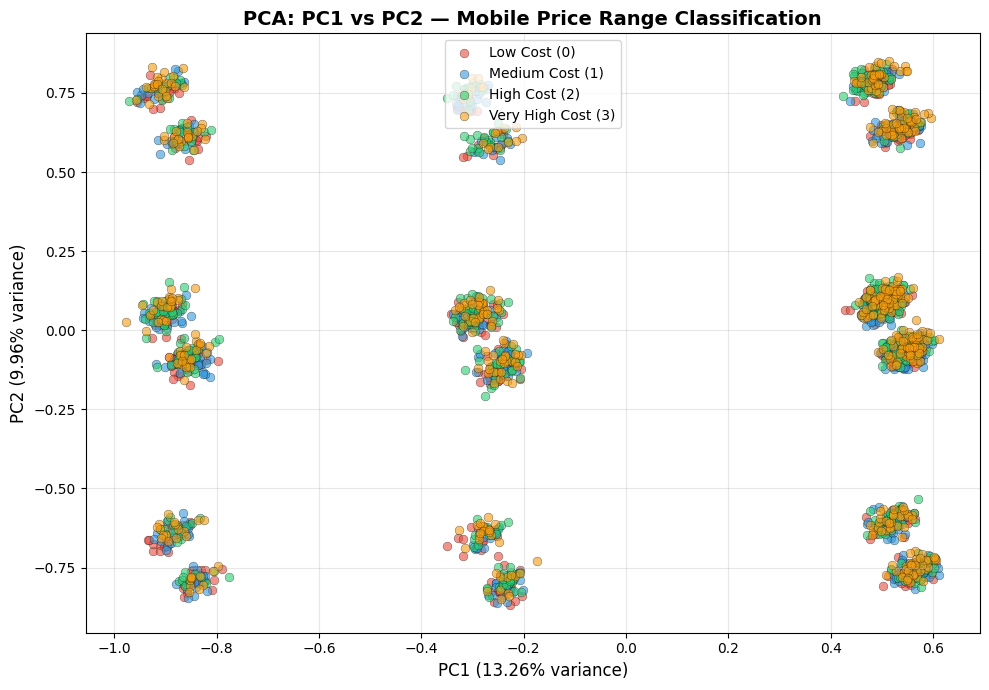

In [4]:
# PCA Scatter Plot: PC1 vs PC2
plt.figure(figsize=(10, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
labels = ['Low Cost (0)', 'Medium Cost (1)', 'High Cost (2)', 'Very High Cost (3)']

for i in range(4):
    mask = y == i
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, edgecolors='k', linewidths=0.3, s=40)

plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title('PCA: PC1 vs PC2 — Mobile Price Range Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### A4 — Observations from PCA Plot:

**Are the price range classes well-separated or overlapping in the PCA plot?**

The price range classes are **largely overlapping** in the PCA plot. While there is a slight trend where class 0 (Low Cost) and class 3 (Very High Cost) tend to occupy different ends of the PC1 axis, the intermediate classes (1 and 2) overlap significantly with each other and with the extreme classes. The boundaries between classes are not clearly defined.

**What does this tell you about using PCA for separating mobile price categories?**

This tells us that PCA alone is **not sufficient** for clearly separating the mobile price categories. PCA is an **unsupervised** technique that finds directions of maximum variance in the data without considering class labels. The maximum variance directions do not necessarily align with the directions that best discriminate between price categories. A **supervised** dimensionality reduction technique like LDA, which explicitly maximizes class separation, would likely produce better-separated clusters.

---
## Part B: Linear Discriminant Analysis (LDA) [5 Marks]

### B1. Apply LDA and Plot LD1 vs LD2 [2 Marks]

LDA Transformed Data Shape: (2000, 2)
Explained Variance Ratio:
  LD1: 0.9968 (99.68%)
  LD2: 0.0024 (0.24%)
  Total: 99.92%


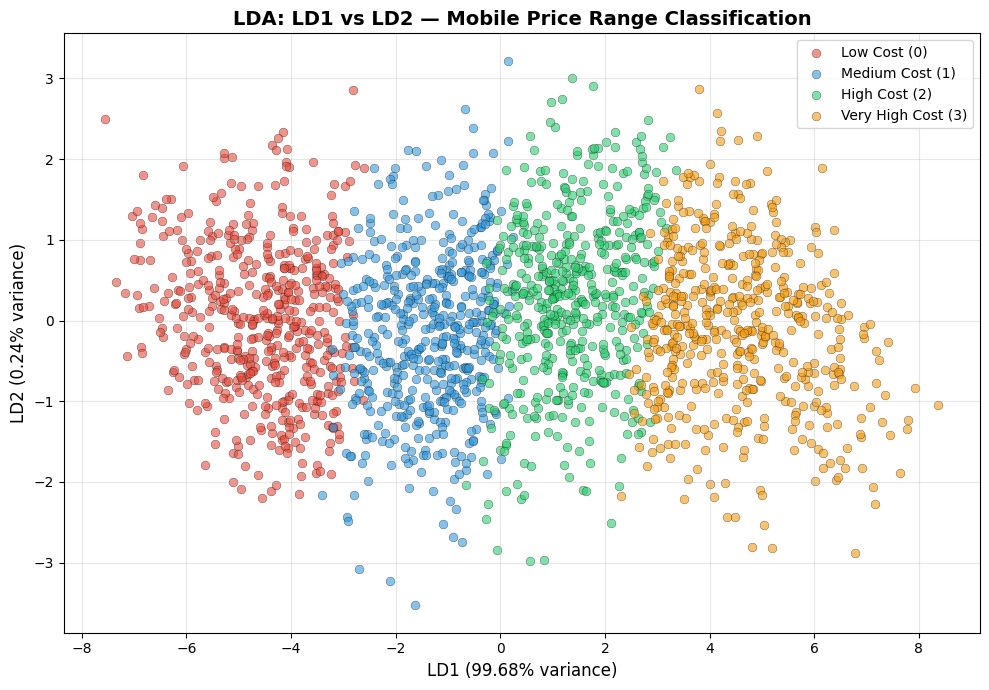

In [5]:
# Apply LDA with 2 components on scaled features
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA Transformed Data Shape:", X_lda.shape)
print(f"Explained Variance Ratio:")
print(f"  LD1: {lda.explained_variance_ratio_[0]:.4f} ({lda.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  LD2: {lda.explained_variance_ratio_[1]:.4f} ({lda.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total: {sum(lda.explained_variance_ratio_)*100:.2f}%")

# LDA Scatter Plot: LD1 vs LD2
plt.figure(figsize=(10, 7))

for i in range(4):
    mask = y == i
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, edgecolors='k', linewidths=0.3, s=40)

plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title('LDA: LD1 vs LD2 — Mobile Price Range Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### B2. Side-by-Side Comparison: PCA vs LDA [2 Marks]

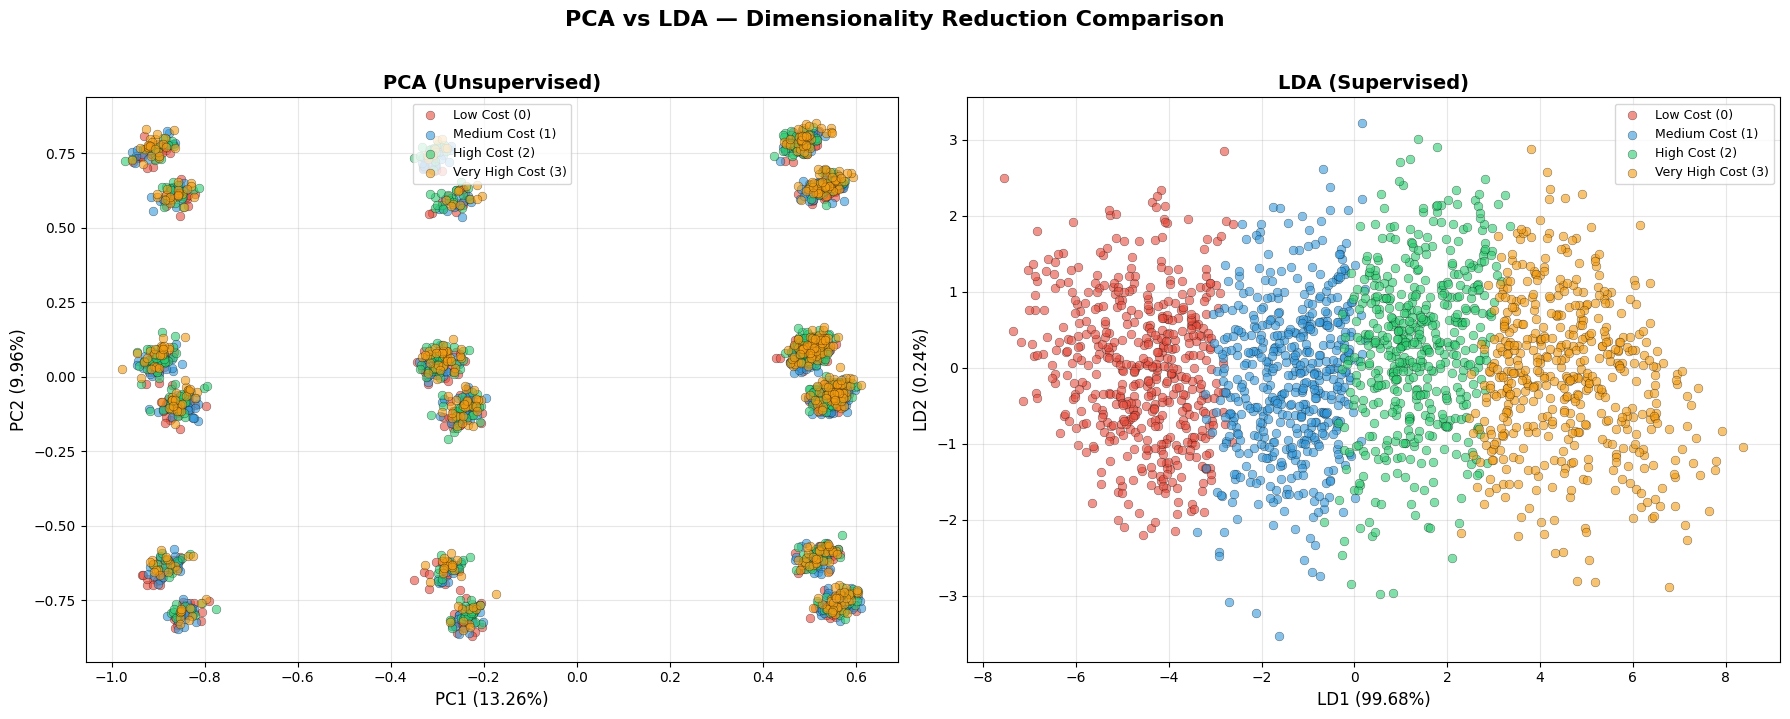

In [6]:
# Side-by-side PCA vs LDA scatter plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PCA Plot ---
for i in range(4):
    mask = y == i
    axes[0].scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                    c=colors[i], label=labels[i], alpha=0.6, edgecolors='k', linewidths=0.3, s=40)
axes[0].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
axes[0].set_title('PCA (Unsupervised)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- LDA Plot ---
for i in range(4):
    mask = y == i
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    c=colors[i], label=labels[i], alpha=0.6, edgecolors='k', linewidths=0.3, s=40)
axes[1].set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
axes[1].set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
axes[1].set_title('LDA (Supervised)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs LDA — Dimensionality Reduction Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### B2 — Observations from Side-by-Side Comparison:

**In which plot are the price range classes more clearly separated?**

The price range classes are **much more clearly separated in the LDA plot** compared to the PCA plot. In the LDA plot, the four price classes form distinct, well-separated clusters, whereas in the PCA plot, the classes overlap heavily in the center.

**Why is LDA better at separating classes than PCA?**

LDA is better because it is a **supervised** technique that explicitly uses the class labels (price_range) to find linear combinations of features that **maximize the between-class variance** while **minimizing the within-class variance**. In contrast, PCA is **unsupervised** — it only finds directions of maximum total variance without any knowledge of class labels. Therefore, PCA may find directions where data spreads out the most, but those directions may not align with class boundaries.

### B3. Conceptual Question [5 Marks]

**PCA vs LDA — Key Differences:**

| Aspect | PCA | LDA |
|--------|-----|-----|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Uses Labels?** | No | Yes |
| **Best For** | General dimensionality reduction, visualization | Classification tasks with labeled data |
| **Components** | Up to min(n_samples, n_features) | Up to (n_classes - 1) |
| **Limitation** | Ignores class structure | Requires labeled data; assumes Gaussian distribution |

**When to use PCA:** When you need to reduce the number of features for visualization, denoising, or speeding up learning algorithms without considering the target variable.

**When to use LDA:** When you have labeled data and the goal is classification — LDA finds the feature space that best separates the known classes.

---
## Part C: Conceptual Questions [3 Marks]

### C1. What does Explained Variance Ratio tell you in PCA?

**Explained Variance Ratio** tells us the **proportion of the dataset's total variance that is captured by each principal component**. It indicates how much information (variance) is retained by each component after dimensionality reduction.

- A higher explained variance ratio means that component captures more information from the original data.
- It helps us decide how many components to keep — we want enough components to capture a significant portion of the total variance.

**If PC1 = 0.62 and PC2 = 0.18, how much total variance is captured by 2 components?**

Total variance captured = PC1 + PC2 = 0.62 + 0.18 = **0.80 (80%)**

This means that the first two principal components together retain 80% of the total variance in the original dataset, while compressing 20 features into just 2 components.

### C2. Maximum Number of LDA Components

**The Mobile Price dataset has 4 price range classes and 20 features. What is the maximum number of components LDA can produce?**

The maximum number of components (linear discriminants) that LDA can produce is:

$$\text{max\_components} = \min(n\_classes - 1, \; n\_features)$$

$$= \min(4 - 1, \; 20) = \min(3, 20) = \textbf{3}$$

**Answer: LDA can produce a maximum of 3 components** from this dataset.

**Reason:** LDA projects data onto a space that maximizes class separability. With *k* classes, LDA can find at most **(k - 1)** discriminant directions because the between-class scatter matrix has a rank of at most (k - 1). Since there are 4 price range classes, LDA can produce at most **4 - 1 = 3** linear discriminants, regardless of the number of features.

In [7]:
# Verification: Apply LDA with maximum components
lda_max = LDA(n_components=3)
X_lda_max = lda_max.fit_transform(X_scaled, y)

print("Verification — LDA with max components:")
print(f"  Number of classes: {len(y.unique())}")
print(f"  Number of features: {X_scaled.shape[1]}")
print(f"  Max LDA components = min(n_classes-1, n_features) = min({len(y.unique())}-1, {X_scaled.shape[1]}) = {min(len(y.unique())-1, X_scaled.shape[1])}")
print(f"  Transformed shape: {X_lda_max.shape}")
print(f"\nExplained Variance Ratio for all 3 LDA components:")
for i, ratio in enumerate(lda_max.explained_variance_ratio_):
    print(f"  LD{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"  Total: {sum(lda_max.explained_variance_ratio_)*100:.2f}%")

Verification — LDA with max components:
  Number of classes: 4
  Number of features: 20
  Max LDA components = min(n_classes-1, n_features) = min(4-1, 20) = 3
  Transformed shape: (2000, 3)

Explained Variance Ratio for all 3 LDA components:
  LD1: 0.9968 (99.68%)
  LD2: 0.0024 (0.24%)
  LD3: 0.0008 (0.08%)
  Total: 100.00%


---
## Summary

| Technique | Type | Components Used | Key Finding |
|-----------|------|----------------|-------------|
| **PCA (2 components)** | Unsupervised | 2 | Classes overlap significantly |
| **PCA (3 components)** | Unsupervised | 3 | Captures more variance but still overlapping |
| **LDA (2 components)** | Supervised | 2 | Classes are well-separated |
| **LDA (3 components)** | Supervised | 3 (max) | Best class separation possible |



**Key Takeaway:** For classification tasks like mobile price prediction, LDA is more effective than PCA for dimensionality reduction because it leverages label information to maximize class separability.